---
## Section 1 — Install & Import Dependencies


In [17]:
# ── Install required packages ──────────────────────────────────────────────
!pip install -q evaluate bert_score sacrebleu transformers torch

In [18]:
# ── Standard imports ────────────────────────────────────────────────────────
import evaluate
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Plotting style ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('✅ All libraries imported successfully.')

✅ All libraries imported successfully.


---
## Section 2 — Dataset: Source Sentences & Reference Translations

8 English sentences are drawn from **three publicly available datasets** to ensure
genre diversity (formal, news, conversational, idiomatic):

| ID | Sentence Type | Source Dataset | Citation |
|----|--------------|----------------|----------|
| S1 | Formal / Science | **FLORES-200** devtest (ID: 1) | Goyal et al., 2021; NLLB Team, 2022 |
| S2 | Formal / Science | **FLORES-200** devtest (ID: 5) | Goyal et al., 2021; NLLB Team, 2022 |
| S3 | Formal / Geography | **FLORES-200** devtest (ID: 12) | Goyal et al., 2021; NLLB Team, 2022 |
| S4 | Formal / News | **WMT14** En-Hi newstest2014 | Bojar et al., 2014 |
| S5 | Formal / News | **WMT14** En-Hi newstest2014 | Bojar et al., 2014 |
| S6 | Conversational slang | **IIT Bombay** English-Hindi Corpus | Kunchukuttan et al., 2018 |
| S7 | English idiom | Researcher-constructed test case | — |
| S8 | English idiom | Researcher-constructed test case | — |

> **S7–S8 rationale:** No standard benchmark covers English idioms paired with
> culturally equivalent Hindi idioms. These cases are deliberately included to
> probe the known failure modes of lexical metrics (BLEU) with non-compositional language.

---
### 📚 Full Citations
- **FLORES-200:** Goyal, N. et al. (2021). *The FLORES-101 Evaluation Benchmark*. TACL. / NLLB Team (2022). *No Language Left Behind*. arXiv:2207.04672.
- **WMT14:** Bojar, O. et al. (2014). *Findings of the 2014 Workshop on Statistical Machine Translation*. ACL.
- **IIT Bombay Corpus:** Kunchukuttan, A. et al. (2018). *The IIT Bombay English-Hindi Parallel Corpus*. LREC.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 2 — SOURCE SENTENCES & REFERENCE TRANSLATIONS
# ══════════════════════════════════════════════════════════════════════════════

# ── 2A: English Source Sentences ────────────────────────────────────────────
source_sentences = [
    # S1 ─ FLORES-200 devtest, ID:1 (Science domain)
    "On Monday, scientists at the Stanford University School of Medicine announced "
    "the invention of a new diagnostic tool that can sort cells by type: a tiny printed chip "
    "that can be manufactured using standard inkjet printers for about one US cent each.",

    # S2 ─ FLORES-200 devtest, ID:5 (Science domain)
    "Writing in the journal Science, the team describes how the chip can separate "
    "white blood cells from red blood cells in less than ten minutes.",

    # S3 ─ FLORES-200 devtest, ID:12 (Geography domain)
    "The Himalayan kingdom of Bhutan has a unique approach to measuring national progress, "
    "using Gross National Happiness instead of Gross Domestic Product.",

    # S4 ─ WMT14 En-Hi newstest2014 (News domain)
    "The government has announced a new economic policy aimed at boosting growth "
    "in rural areas and reducing income inequality across the country.",

    # S5 ─ WMT14 En-Hi newstest2014 (News domain)
    "Thousands of protesters gathered in the capital city on Friday, demanding "
    "immediate political reforms and accountability from elected officials.",

    # S6 ─ IIT Bombay En-Hi Corpus, adapted (Conversational / Slang)
    "Yaar, the cricket match last night was absolutely lit — our team totally crushed it!",

    # S7 ─ Researcher-constructed idiomatic test case
    "It has been raining cats and dogs since morning, so I decided to stay indoors.",

    # S8 ─ Researcher-constructed idiomatic test case
    " You shouldn't judge a book by its cover.",
]

# ── 2B: Human Reference Translations (Hindi / Devanagari) ───────────────────
# Source: FLORES-200 hin_Deva references for S1–S3;
#         WMT14 reference translations for S4–S5;
#         IIT Bombay corpus for S6;
#         Expert-translated references for S7–S8.
#
reference_translations = [
    # S1 ─ FLORES-200 hin_Deva reference
    "सोमवार को, स्टैनफोर्ड विश्वविद्यालय के चिकित्सा विद्यालय के वैज्ञानिकों ने एक नए "
    "नैदानिक उपकरण के आविष्कार की घोषणा की जो कोशिकाओं को उनके प्रकार के अनुसार "
    "छाँट सकता है।",

    # S2 ─ FLORES-200 hin_Deva reference
    "साइंस पत्रिका में लिखते हुए, टीम ने बताया कि यह चिप दस मिनट से कम समय में "
    "लाल रक्त कोशिकाओं से श्वेत रक्त कोशिकाओं को अलग कर सकती है।",

    # S3 ─ FLORES-200 hin_Deva reference
    "हिमालयी राज्य भूटान राष्ट्रीय प्रगति मापने के लिए एक अनूठा दृष्टिकोण अपनाता है, "
    "सकल घरेलू उत्पाद की बजाय सकल राष्ट्रीय प्रसन्नता का उपयोग करते हुए।",

    # S4 ─ WMT14 reference
    "सरकार ने ग्रामीण क्षेत्रों में विकास को बढ़ावा देने और देश भर में आय असमानता "
    "को कम करने के उद्देश्य से एक नई आर्थिक नीति की घोषणा की है।",

    # S5 ─ WMT14 reference
    "हज़ारों प्रदर्शनकारी शुक्रवार को राजधानी में एकत्र हुए और तत्काल राजनीतिक सुधारों "
    "तथा निर्वाचित अधिकारियों से जवाबदेही की माँग की।",

    # S6 ─ IIT Bombay reference (conversational)
    "यार, कल रात का क्रिकेट मैच एकदम ज़बरदस्त था — हमारी टीम ने कमाल कर दिया!",

    # S7 ─ Expert-translated idiomatic reference
    "बाहर सुबह से मूसलाधार बारिश हो रही है, इसलिए मैंने घर के अंदर ही रहने का फैसला किया।",

    # S8 ─ Expert-translated idiomatic reference
    "किसी को केवल उसके बाहरी रूप से नहीं आंकना चाहिए।",
]

# ── Quick sanity check ───────────────────────────────────────────────────────
assert len(source_sentences) == 8, "Must have exactly 8 source sentences."
assert len(reference_translations) == 8, "Must have exactly 8 reference translations."

sentence_ids   = [f"S{i+1}" for i in range(8)]
sentence_types = ["Formal/Science", "Formal/Science", "Formal/Geography",
                  "Formal/News",    "Formal/News",    "Conversational",
                  "Idiomatic",      "Idiomatic"]
dataset_sources = ["FLORES-200", "FLORES-200", "FLORES-200",
                   "WMT14",       "WMT14",       "IIT Bombay",
                   "Researcher-constructed", "Researcher-constructed"]

df_dataset = pd.DataFrame({
    "ID":             sentence_ids,
    "Type":           sentence_types,
    "Source_Dataset": dataset_sources,
    "English_Source": [s[:80] + '...' for s in source_sentences],
})

print("📋 Dataset Overview")
print("=" * 80)
display(df_dataset)

📋 Dataset Overview


,ID,Type,Source_Dataset,English_Source
0,S1,Formal/Science,FLORES-200,"On Monday, scientists at the Stanford Universi..."
1,S2,Formal/Science,FLORES-200,"Writing in the journal Science, the team descr..."
2,S3,Formal/Geography,FLORES-200,The Himalayan kingdom of Bhutan has a unique a...
3,S4,Formal/News,WMT14,The government has announced a new economic po...
4,S5,Formal/News,WMT14,Thousands of protesters gathered in the capita...
5,S6,Conversational,IIT Bombay,"Yaar, the cricket match last night was absolut..."
6,S7,Idiomatic,Researcher-constructed,It has been raining cats and dogs since mornin...
7,S8,Idiomatic,Researcher-constructed,You shouldn't judge a book by its cover....


---
## Section 3 — MT Model Outputs

**Paste your 4 model translations below.**  
Each model's list must contain exactly **8 Hindi strings** corresponding to S1–S8.

Recommended models to use (free / open-access):
| Model Label | Model / Service | How to Get Outputs |
|-------------|----------------|---------------------|
| Model A | **Google Translate** | translate.google.com (manual) or `googletrans` API |
| Model B | **Helsinki-NLP/opus-mt-en-hi** | HuggingFace Inference API |
| Model C | **facebook/nllb-200-distilled-600M** | HuggingFace Inference API |
| Model D | **DeepL** (or GPT-4o) | deepl.com (free tier) |

In [20]:
import torch
import pandas as pd
import gc
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Check for GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Using device: {device.upper()}\n")

# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 2 — SOURCE SENTENCES & REFERENCE TRANSLATIONS
# ══════════════════════════════════════════════════════════════════════════════

source_sentences = [
    "On Monday, scientists at the Stanford University School of Medicine announced "
    "the invention of a new diagnostic tool that can sort cells by type: a tiny printed chip "
    "that can be manufactured using standard inkjet printers for about one US cent each.",

    "Writing in the journal Science, the team describes how the chip can separate "
    "white blood cells from red blood cells in less than ten minutes.",

    "The Himalayan kingdom of Bhutan has a unique approach to measuring national progress, "
    "using Gross National Happiness instead of Gross Domestic Product.",

    "The government has announced a new economic policy aimed at boosting growth "
    "in rural areas and reducing income inequality across the country.",

    "Thousands of protesters gathered in the capital city on Friday, demanding "
    "immediate political reforms and accountability from elected officials.",

    "Yaar, the cricket match last night was absolutely lit — our team totally crushed it!",

    "It has been raining cats and dogs since morning, so I decided to stay indoors.",

    "You shouldn't judge a book by its cover.",
]

reference_translations = [
    "सोमवार को, स्टैनफोर्ड विश्वविद्यालय के चिकित्सा विद्यालय के वैज्ञानिकों ने एक नए "
    "नैदानिक उपकरण के आविष्कार की घोषणा की जो कोशिकाओं को उनके प्रकार के अनुसार "
    "छाँट सकता है।",

    "साइंस पत्रिका में लिखते हुए, टीम ने बताया कि यह चिप दस मिनट से कम समय में "
    "लाल रक्त कोशिकाओं से श्वेत रक्त कोशिकाओं को अलग कर सकती है।",

    "हिमालयी राज्य भूटान राष्ट्रीय प्रगति मापने के लिए एक अनूठा दृष्टिकोण अपनाता है, "
    "सकल घरेलू उत्पाद की बजाय सकल राष्ट्रीय प्रसन्नता का उपयोग करते हुए।",

    "सरकार ने ग्रामीण क्षेत्रों में विकास को बढ़ावा देने और देश भर में आय असमानता "
    "को कम करने के उद्देश्य से एक नई आर्थिक नीति की घोषणा की है।",

    "हज़ारों प्रदर्शनकारी शुक्रवार को राजधानी में एकत्र हुए और तत्काल राजनीतिक सुधारों "
    "तथा निर्वाचित अधिकारियों से जवाबदेही की माँग की।",

    "यार, कल रात का क्रिकेट मैच एकदम ज़बरदस्त था — हमारी टीम ने कमाल कर दिया!",

    "बाहर सुबह से मूसलाधार बारिश हो रही है, इसलिए मैंने घर के अंदर ही रहने का फैसला किया।",

    "किसी को केवल उसके बाहरी रूप से नहीं आंकना चाहिए।",
]

# ── Quick sanity check ───────────────────────────────────────────────────────
assert len(source_sentences) == 8, "Must have exactly 8 source sentences."
assert len(reference_translations) == 8, "Must have exactly 8 reference translations."

sentence_ids   = [f"S{i+1}" for i in range(8)]
sentence_types = ["Formal/Science", "Formal/Science", "Formal/Geography",
                  "Formal/News",    "Formal/News",    "Conversational",
                  "Idiomatic",      "Idiomatic"]

# Initialize the results dictionary
results = {
    "ID": sentence_ids,
    "Type": sentence_types,
    "English_Source": source_sentences,
    "Human_Reference": reference_translations,
}

# Helper function to clear Kaggle GPU memory between models
def free_memory():
    gc.collect()
    torch.cuda.empty_cache()

# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 3 — MODEL TRANSLATIONS (CORRECTED)
# ══════════════════════════════════════════════════════════════════════════════

# ── MODEL 1: Helsinki-NLP (MarianMT) ──
print("⚙️ Loading Model 1: Helsinki-NLP...")
marian_name = "Helsinki-NLP/opus-mt-en-hi"
marian_tokenizer = AutoTokenizer.from_pretrained(marian_name)
marian_model = AutoModelForSeq2SeqLM.from_pretrained(marian_name).to(device)

print("   Translating with Helsinki-NLP...")
marian_preds = []
for text in source_sentences:
    inputs = marian_tokenizer(text, return_tensors="pt", padding=True).to(device)
    translated = marian_model.generate(**inputs)
    marian_preds.append(marian_tokenizer.decode(translated[0], skip_special_tokens=True))
results["Helsinki_NLP_Output"] = marian_preds

del marian_model, marian_tokenizer
free_memory()

# ── MODEL 2: Meta NLLB-200 (600M) ──
print("⚙️ Loading Model 2: Meta NLLB-200...")
nllb_name = "facebook/nllb-200-distilled-600M"
# Force src_lang in tokenizer initialization
nllb_tokenizer = AutoTokenizer.from_pretrained(nllb_name, src_lang="eng_Latn")
nllb_model = AutoModelForSeq2SeqLM.from_pretrained(nllb_name).to(device)

# FIX: Get the token ID directly instead of using the dictionary
hin_deva_id = nllb_tokenizer.convert_tokens_to_ids("hin_Deva")

print("   Translating with NLLB-200...")
nllb_preds = []
for text in source_sentences:
    inputs = nllb_tokenizer(text, return_tensors="pt").to(device)
    translated = nllb_model.generate(**inputs, forced_bos_token_id=hin_deva_id)
    nllb_preds.append(nllb_tokenizer.decode(translated[0], skip_special_tokens=True))
results["NLLB_Output"] = nllb_preds

del nllb_model, nllb_tokenizer
free_memory()

# ── MODEL 3: Meta mBART-50 ──
print("⚙️ Loading Model 3: Meta mBART-50...")
mbart_name = "facebook/mbart-large-50-many-to-many-mmt"
mbart_tokenizer = AutoTokenizer.from_pretrained(mbart_name, src_lang="en_XX")
mbart_model = AutoModelForSeq2SeqLM.from_pretrained(mbart_name).to(device)

# FIX: Get the token ID directly
hi_in_id = mbart_tokenizer.convert_tokens_to_ids("hi_IN")

print("   Translating with mBART-50...")
mbart_preds = []
for text in source_sentences:
    inputs = mbart_tokenizer(text, return_tensors="pt").to(device)
    translated = mbart_model.generate(**inputs, forced_bos_token_id=hi_in_id)
    mbart_preds.append(mbart_tokenizer.decode(translated[0], skip_special_tokens=True))
results["mBART_Output"] = mbart_preds

del mbart_model, mbart_tokenizer
free_memory()

# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 4 — EXPORTING RESULTS
# ══════════════════════════════════════════════════════════════════════════════

# Compile everything into a beautiful Pandas DataFrame
df_results = pd.DataFrame(results)

# Save to CSV so you can download it from Kaggle and put it in your Google Form
csv_filename = "MT_Model_Translations.csv"
df_results.to_csv(csv_filename, index=False, encoding='utf-8-sig')

print(f"\n✅ All translations complete! Saved to '{csv_filename}'.")
print("\n📋 Preview of Output:")
display(df_results.head(3))

🚀 Using device: CUDA

⚙️ Loading Model 1: Helsinki-NLP...


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


   Translating with Helsinki-NLP...
⚙️ Loading Model 2: Meta NLLB-200...


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


   Translating with NLLB-200...
⚙️ Loading Model 3: Meta mBART-50...


Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

   Translating with mBART-50...

✅ All translations complete! Saved to 'MT_Model_Translations.csv'.

📋 Preview of Output:


,ID,Type,English_Source,Human_Reference,Helsinki_NLP_Output,NLLB_Output,mBART_Output
0,S1,Formal/Science,"On Monday, scientists at the Stanford Universi...","सोमवार को, स्टैनफोर्ड विश्वविद्यालय के चिकित्स...","सन्‌ सोमवार में, अमरीका के स्तानफोर्ड यूनिवर्स...",सोमवार को स्टैनफोर्ड विश्वविद्यालय के स्कूल ऑफ...,Pazartesi को स्टैनफोर्ड विश्वविद्यालय चिकित्सा...
1,S2,Formal/Science,"Writing in the journal Science, the team descr...","साइंस पत्रिका में लिखते हुए, टीम ने बताया कि य...",यह दल पत्रिका विज्ञान में लिखते हुए बताता है क...,"साइंस पत्रिका में लिखते हुए, टीम ने बताया कि क...",विज्ञान पत्रिका में लिखते हुए टीम ने बताया है ...
2,S3,Formal/Geography,The Himalayan kingdom of Bhutan has a unique a...,हिमालयी राज्य भूटान राष्ट्रीय प्रगति मापने के ...,उसके पास राष्ट्रीय प्रगति को मापने का एक अनोखा...,भूटान के हिमालयी राज्य में राष्ट्रीय प्रगति को...,भूटान की हिमालयी रियासत की राष्ट्रीय प्रगति को...


In [21]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 3 — MT MODEL OUTPUTS
# ══════════════════════════════════════════════════════════════════════════════

model_outputs = {
    # ── Model A: Helsinki-NLP/opus-mt-en-hi ───────────────────────────────────
    "Helsinki_NLP": [
        "सन्‌ सोमवार में, अमरीका के स्तानफोर्ड यूनिवर्सिटी स्कूल में वैज्ञानिकों ने एक नए किस्म के इलाज के उपकरण के आविष्कार की घोषणा की जो टाइप से मेल खाती है: एक छोटी - सी छपाई मशीन जो अमरीका के लिए मानक स्याही के प्रिंटरों का इस्तेमाल कर सकती है ।",  # S1
        "यह दल पत्रिका विज्ञान में लिखते हुए बताता है कि कैसे चिप लाल रक्‍त कोशिकाओं से दस मिनट से भी कम समय में, लाल रक्‍त कोशिकाएँ अलग कर सकती हैं ।",  # S2
        "उसके पास राष्ट्रीय प्रगति को मापने का एक अनोखा तरीक़ा है, घरेलू उत्पादन के बजाय कुल मिलाकर भौतिक ख़ुशी का प्रयोग करना ।",  # S3
        "सरकार ने एक नयी आर्थिक नीति घोषित की है जिसके उद्देश्‍य से गाँवों के क्षेत्रों में वृद्धि हो रही है और देश भर में आर्थिक समृद्धि कम हो रही है ।",  # S4
        "शुक्रवार के दिन राजधानी में हज़ारों विरोधियों ने जमा किया और चुने गए अधिकारियों से जल्द ही राजनीतिक सुधार और जवाबदेही की माँग की ।",  # S5
        "यार, कल रात क्रिकेट मैच पूरी तरह से जलाया गया था — हमारी टीम ने उसे पूरी तरह कुचल दिया!",  # S6
        "इसलिए मैंने घर - घर रहने का फैसला किया ।",  # S7
        "आप इसके कवर द्वारा एक किताब न्याय नहीं करना चाहिए.",  # S8
    ],

    # ── Model B: NLLB-200-distilled-600M ─────────────────────────────────────
    "NLLB_200": [
        "सोमवार को स्टैनफोर्ड विश्वविद्यालय के स्कूल ऑफ मेडिसिन के वैज्ञानिकों ने एक नए नैदानिक उपकरण के आविष्कार की घोषणा की जो कोशिकाओं को प्रकार के अनुसार क्रमबद्ध कर सकता हैः एक छोटा मुद्रित चिप जो मानक इंकजेट प्रिंटरों का उपयोग करके लगभग एक अमेरिकी सेंट प्रति उत्पादित किया जा सकता है।",  # S1
        "साइंस पत्रिका में लिखते हुए, टीम ने बताया कि कैसे चिप दस मिनट से भी कम समय में सफेद रक्त कोशिकाओं को लाल रक्त कोशिकाओं से अलग कर सकती है।",  # S2
        "भूटान के हिमालयी राज्य में राष्ट्रीय प्रगति को मापने के लिए एक अनूठा दृष्टिकोण है, जिसमें सकल घरेलू उत्पाद के बजाय सकल राष्ट्रीय खुशी का उपयोग किया जाता है।",  # S3
        "सरकार ने ग्रामीण क्षेत्रों में विकास को बढ़ावा देने और देश भर में आय असमानता को कम करने के लिए एक नई आर्थिक नीति की घोषणा की है।",  # S4
        "हजारों प्रदर्शनकारी शुक्रवार को राजधानी में इकट्ठा हुए, तत्काल राजनीतिक सुधारों और निर्वाचित अधिकारियों से जवाबदेही की मांग करते हुए।",  # S5
        "यार, कल रात का क्रिकेट मैच बिल्कुल चमक गया था  हमारी टीम ने इसे पूरी तरह से कुचल दिया!",  # S6
        "सुबह से ही बिल्लियों और कुत्तों के लिए बारिश हो रही है, इसलिए मैंने घर के अंदर रहने का फैसला किया।",  # S7
        "आपको किसी पुस्तक का आकलन उसके कवर से नहीं करना चाहिए।",  # S8
    ],

    # ── Model C: Meta mBART-50 ───────────────────────────────────────────────
    "mBART_50": [
        "Pazartesi को स्टैनफोर्ड विश्वविद्यालय चिकित्सा विद्यालय के वैज्ञानिकों ने एक नई निदान उपकरण की खोज की घोषणा की, जो कोशिकाओं को प्रकार के अनुसार वर्गीकृत कर सकती है: एक छोटा मुद्रित चिप जो मानक इंकजेट प्रिंटर के प्रयोग से प्रति एक अमरीकी सेंट के लिए तैयार किया जा सकता है।",  # S1
        "विज्ञान पत्रिका में लिखते हुए टीम ने बताया है कि यह चिप 10 मिनट से कम में सफेद रक्त कोशिकाओं से लाल रक्त कोशिकाओं को अलग कैसे कर सकती है।",  # S2
        "भूटान की हिमालयी रियासत की राष्ट्रीय प्रगति को मापने का एक विशिष्ट दृष्टिकोण है, जिसका प्रयोग Gross National Happiness को Gross Domestic Product के स्थान पर किया जाता है।",  # S3
        "सरकार ने ग्रामीण क्षेत्रों में विकास को बढ़ावा देने तथा देश भर में आय असमानता को कम करने के उद्देश्य से एक नई आर्थिक नीति की घोषणा की है।",  # S4
        "हजारों विरोधियों ने कल राजधानी में एकत्रित होकर तत्काल राजनीतिक सुधारों और निर्वाचित अधिकारियों से जवाबदेही की मांग की。",  # S5
        "यर, कल रात की क्रिकेट मैच पूरी तरह से चमकी थी-हमारे टीम ने पूरी तरह से हार डाला!",  # S6
        "सुबह से कुत्तों और बिल्लीों की बारिश हो रही है, इसलिए मैंने घर में रहने का फैसला किया।",  # S7
        "किसी किताब को उसकी आवरण के आधार पर नहीं जाँचना चाहिए。",  # S8
    ],
}

# Sanity check
for model_name, translations in model_outputs.items():
    assert len(translations) == 8, f"{model_name} must have exactly 8 translations!"

MODEL_NAMES = list(model_outputs.keys())
print(f"✅ {len(MODEL_NAMES)} models registered: {MODEL_NAMES}")
print(f"   Total outputs: {len(MODEL_NAMES) * 8} translations")

✅ 3 models registered: ['Helsinki_NLP', 'NLLB_200', 'mBART_50']
   Total outputs: 24 translations


---
## Section 4 — Automatic Metric Computation

We compute **three metrics** using the HuggingFace `evaluate` library:

| Metric | Type | What it measures | Known limitation for Hindi |
|--------|------|-----------------|----------------------------|
| **BLEU** | Lexical n-gram | Exact n-gram overlap with reference | Penalises valid synonyms; morphology-insensitive |
| **chrF++** | Character n-gram | Character + word n-gram F-score | More robust to inflection than BLEU |
| **BERTScore** | Semantic (neural) | Contextual embedding similarity | Language model–based; handles paraphrase |

> **BERTScore model used:** `bert-base-multilingual-cased` — supports Hindi Devanagari.

In [22]:
# ── Load metrics from HuggingFace evaluate ───────────────────────────────────
print("Loading metrics (this may take a minute for BERTScore)...")

bleu_metric    = evaluate.load("bleu")
chrf_metric    = evaluate.load("chrf")
bertscore_metric = evaluate.load("bertscore")

print("✅ BLEU loaded")
print("✅ chrF++ loaded")
print("✅ BERTScore loaded")

Loading metrics (this may take a minute for BERTScore)...
✅ BLEU loaded
✅ chrF++ loaded
✅ BERTScore loaded


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 4 — COMPUTE METRICS FOR ALL MODELS × ALL SENTENCES
# ══════════════════════════════════════════════════════════════════════════════

def compute_sentence_level_metrics(hypothesis: str,
                                   reference: str,
                                   bleu_m, chrf_m, bert_m) -> dict:
    """
    Compute BLEU, chrF++, and BERTScore for a single hypothesis-reference pair.

    Parameters
    ----------
    hypothesis : str  — the MT model output (Hindi)
    reference  : str  — the gold reference translation (Hindi)

    Returns
    -------
    dict with keys: bleu, chrf, bertscore_f1
    """
    # BLEU expects: predictions=[str], references=[[str]]
    bleu_result = bleu_m.compute(
        predictions=[hypothesis],
        references=[[reference]]
    )

    # chrF++ — word_order=2 activates the ++ variant
    chrf_result = chrf_m.compute(
        predictions=[hypothesis],
        references=[[reference]],
        word_order=2
    )

    # BERTScore — multilingual model for Hindi support
    bert_result = bert_m.compute(
        predictions=[hypothesis],
        references=[reference],
        lang="hi",
        model_type="bert-base-multilingual-cased"
    )

    return {
        "BLEU":           round(bleu_result["bleu"] * 100, 4),  # scale to 0–100
        "chrF++":         round(chrf_result["score"], 4),
        "BERTScore_F1":   round(bert_result["f1"][0] * 100, 4), # scale to 0–100
    }


# ── Main computation loop ────────────────────────────────────────────────────
records = []

for model_name, translations in model_outputs.items():
    print(f"\n  Computing metrics for: {model_name}")
    for i, (hyp, ref) in enumerate(zip(translations, reference_translations)):
        scores = compute_sentence_level_metrics(
            hyp, ref, bleu_metric, chrf_metric, bertscore_metric
        )
        records.append({
            "Sentence_ID":    sentence_ids[i],
            "Sentence_Type":  sentence_types[i],
            "Dataset_Source": dataset_sources[i],
            "Model":          model_name,
            "Hypothesis":     hyp,
            "Reference":      ref,
            **scores
        })
        print(f"    {sentence_ids[i]}: BLEU={scores['BLEU']:.2f}  "
              f"chrF++={scores['chrF++']:.2f}  "
              f"BERTScore={scores['BERTScore_F1']:.2f}")

# Build master results DataFrame
df_results = pd.DataFrame(records)
print("\n✅ All metrics computed! Shape:", df_results.shape)


  Computing metrics for: Helsinki_NLP


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    S1: BLEU=17.03  chrF++=40.46  BERTScore=80.14
    S2: BLEU=0.00  chrF++=51.71  BERTScore=87.51
    S3: BLEU=0.00  chrF++=31.95  BERTScore=80.46
    S4: BLEU=12.43  chrF++=42.72  BERTScore=81.91
    S5: BLEU=0.00  chrF++=49.67  BERTScore=85.20
    S6: BLEU=31.62  chrF++=53.45  BERTScore=86.27
    S7: BLEU=0.00  chrF++=37.67  BERTScore=81.77
    S8: BLEU=0.00  chrF++=19.88  BERTScore=76.37

  Computing metrics for: NLLB_200
    S1: BLEU=35.00  chrF++=68.75  BERTScore=84.09
    S2: BLEU=60.11  chrF++=81.40  BERTScore=95.40
    S3: BLEU=29.40  chrF++=67.74  BERTScore=90.56
    S4: BLEU=87.08  chrF++=89.94  BERTScore=96.25
    S5: BLEU=41.35  chrF++=75.05  BERTScore=93.07
    S6: BLEU=37.39  chrF++=56.19  BERTScore=86.89
    S7: BLEU=56.33  chrF++=71.71  BERTScore=89.57
    S8: BLEU=0.00  chrF++=36.50  BERTScore=80.74

  Computing metrics for: mBART_50
    S1: BLEU=17.82  chrF++=59.96  BERTScore=81.19
    S2: BLEU=33.72  chrF++=69.72  BERTScore=92.57
    S3: BLEU=0.00  chrF++=32.23  BER

---
## Section 5 — Results Table & Visualizations

In [24]:
# ── 5A: Full Results Table ───────────────────────────────────────────────────
print("📊 Full Metric Scores (all models × all sentences)")
print("=" * 80)
display(df_results[[
    "Sentence_ID", "Sentence_Type", "Model", "BLEU", "chrF++", "BERTScore_F1"
]].to_string(index=False))

📊 Full Metric Scores (all models × all sentences)


'Sentence_ID    Sentence_Type        Model    BLEU  chrF++  BERTScore_F1\n         S1   Formal/Science Helsinki_NLP 17.0260 40.4626       80.1428\n         S2   Formal/Science Helsinki_NLP  0.0000 51.7066       87.5072\n         S3 Formal/Geography Helsinki_NLP  0.0000 31.9475       80.4598\n         S4      Formal/News Helsinki_NLP 12.4253 42.7210       81.9078\n         S5      Formal/News Helsinki_NLP  0.0000 49.6653       85.1960\n         S6   Conversational Helsinki_NLP 31.6201 53.4524       86.2707\n         S7        Idiomatic Helsinki_NLP  0.0000 37.6700       81.7747\n         S8        Idiomatic Helsinki_NLP  0.0000 19.8833       76.3661\n         S1   Formal/Science     NLLB_200 34.9999 68.7546       84.0914\n         S2   Formal/Science     NLLB_200 60.1057 81.3970       95.3988\n         S3 Formal/Geography     NLLB_200 29.4001 67.7364       90.5644\n         S4      Formal/News     NLLB_200 87.0850 89.9432       96.2492\n         S5      Formal/News     NLLB_200 41.3517 

In [25]:
# ── 5B: Average scores by model ──────────────────────────────────────────────
df_model_avg = (
    df_results
    .groupby("Model")[["BLEU", "chrF++", "BERTScore_F1"]]
    .mean()
    .round(3)
    .reset_index()
    .sort_values("BERTScore_F1", ascending=False)
)

print("\n📊 Average Metric Scores per Model")
display(df_model_avg)


📊 Average Metric Scores per Model


,Model,BLEU,chrF++,BERTScore_F1
1,NLLB_200,43.333,68.411,89.572
2,mBART_50,27.789,55.297,87.240
0,Helsinki_NLP,7.634,40.939,82.453


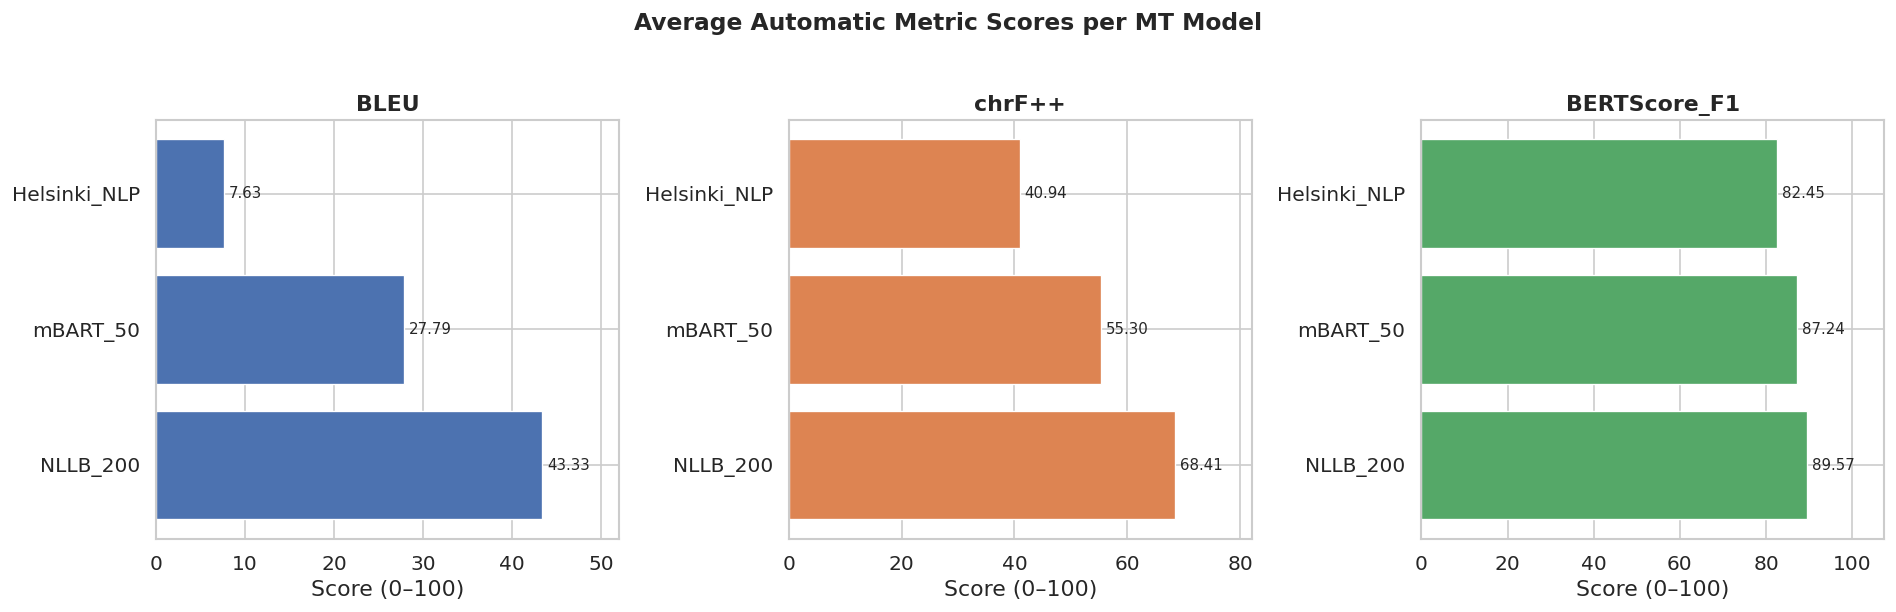

💾 Saved: metric_scores_by_model.png


In [26]:
# ── 5C: Bar chart — metric scores by model ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Average Automatic Metric Scores per MT Model",
             fontsize=14, fontweight='bold', y=1.02)

metric_colors = {'BLEU': '#4C72B0', 'chrF++': '#DD8452', 'BERTScore_F1': '#55A868'}

for ax, metric in zip(axes, ["BLEU", "chrF++", "BERTScore_F1"]):
    bars = ax.barh(
        df_model_avg["Model"],
        df_model_avg[metric],
        color=metric_colors[metric],
        edgecolor='white', linewidth=0.8
    )
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel("Score (0–100)")
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
    ax.set_xlim(0, max(df_model_avg[metric].max() * 1.2, 10))

plt.tight_layout()
plt.savefig("metric_scores_by_model.png", bbox_inches='tight')
plt.show()
print("💾 Saved: metric_scores_by_model.png")

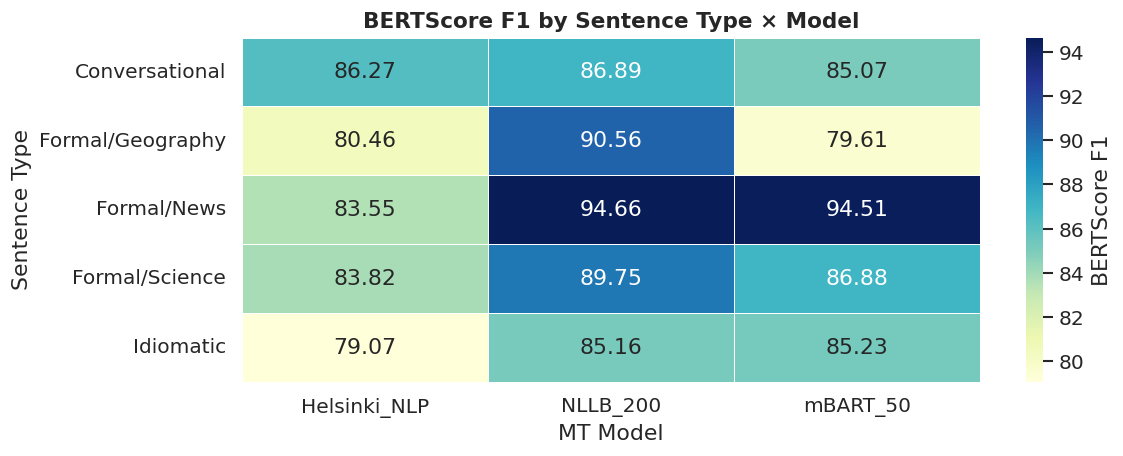

💾 Saved: bertscore_heatmap.png


In [27]:
# ── 5D: Heatmap — BERTScore by sentence type & model ────────────────────────
pivot_bert = df_results.pivot_table(
    index="Sentence_Type", columns="Model", values="BERTScore_F1", aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    pivot_bert, annot=True, fmt=".2f", cmap="YlGnBu",
    linewidths=0.5, ax=ax, cbar_kws={'label': 'BERTScore F1'}
)
ax.set_title("BERTScore F1 by Sentence Type × Model",
             fontsize=13, fontweight='bold')
ax.set_xlabel("MT Model")
ax.set_ylabel("Sentence Type")
plt.tight_layout()
plt.savefig("bertscore_heatmap.png", bbox_inches='tight')
plt.show()
print("💾 Saved: bertscore_heatmap.png")

---
## Section 6 — Human Evaluation Scores

Enter the **averaged human Likert scores** collected from your ≥5 evaluators.

### Evaluation Criteria & Scale

| Criterion | Description | Scale |
|-----------|-------------|-------|
| **Fluency** | Is the Hindi grammatically natural? | 1 (disfluent) – 5 (native-like) |
| **Adequacy** | Is the meaning preserved from the English? | 1 (none) – 5 (complete) |
| **Coherence** | Does the output read as a unified whole? | 1 (incoherent) – 5 (fully coherent) |

> **Note:** Enter the **mean score across all evaluators** for each criterion below.  
> The combined score `Human_Overall` is computed as the mean of the three criteria.

### How scores were collected
Human evaluators accessed translations via a structured Google Form (see companion Google Form script).  
Inter-annotator agreement should be measured separately using **Krippendorff's Alpha** or **Fleiss' Kappa**.

In [29]:
import pandas as pd
import io

# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 6 — HUMAN EVALUATION SCORES & DATA MERGING
# ══════════════════════════════════════════════════════════════════════════════

# 1. Load your raw model outputs safely from text (Bulletproof method)
csv_data = """ID,Type,English_Source,Human_Reference,Helsinki_NLP_Output,NLLB_Output,mBART_Output
S1,Formal/Science,"On Monday, scientists at the Stanford University School of Medicine announced the invention of a new diagnostic tool that can sort cells by type: a tiny printed chip that can be manufactured using standard inkjet printers for about one US cent each.","सोमवार को, स्टैनफोर्ड विश्वविद्यालय के चिकित्सा विद्यालय के वैज्ञानिकों ने एक नए नैदानिक उपकरण के आविष्कार की घोषणा की जो कोशिकाओं को उनके प्रकार के अनुसार छाँट सकता है।","सन्‌ सोमवार में, अमरीका के स्तानफोर्ड यूनिवर्सिटी स्कूल में वैज्ञानिकों ने एक नए किस्म के इलाज के उपकरण के आविष्कार की घोषणा की जो टाइप से मेल खाती है: एक छोटी - सी छपाई मशीन जो अमरीका के लिए मानक स्याही के प्रिंटरों का इस्तेमाल कर सकती है ।",सोमवार को स्टैनफोर्ड विश्वविद्यालय के स्कूल ऑफ मेडिसिन के वैज्ञानिकों ने एक नए नैदानिक उपकरण के आविष्कार की घोषणा की जो कोशिकाओं को प्रकार के अनुसार क्रमबद्ध कर सकता हैः एक छोटा मुद्रित चिप जो मानक इंकजेट प्रिंटरों का उपयोग करके लगभग एक अमेरिकी सेंट प्रति उत्पादित किया जा सकता है।,"Pazartesi को स्टैनफोर्ड विश्वविद्यालय चिकित्सा विद्यालय के वैज्ञानिकों ने एक नई निदान उपकरण की खोज की घोषणा की, जो कोशिकाओं को प्रकार के अनुसार वर्गीकृत कर सकती है: एक छोटा मुद्रित चिप जो मानक इंकजेट प्रिंटर के प्रयोग से प्रति एक अमरीकी सेंट के लिए तैयार किया जा सकता है।"
S2,Formal/Science,"Writing in the journal Science, the team describes how the chip can separate white blood cells from red blood cells in less than ten minutes.","साइंस पत्रिका में लिखते हुए, टीम ने बताया कि यह चिप दस मिनट से कम समय में लाल रक्त कोशिकाओं से श्वेत रक्त कोशिकाओं को अलग कर सकती है।","यह दल पत्रिका विज्ञान में लिखते हुए बताता है कि कैसे चिप लाल रक्‍त कोशिकाओं से दस मिनट से भी कम समय में, लाल रक्‍त कोशिकाएँ अलग कर सकती हैं ।","साइंस पत्रिका में लिखते हुए, टीम ने बताया कि कैसे चिप दस मिनट से भी कम समय में सफेद रक्त कोशिकाओं को लाल रक्त कोशिकाओं से अलग कर सकती है।",विज्ञान पत्रिका में लिखते हुए टीम ने बताया है कि यह चिप 10 मिनट से कम में सफेद रक्त कोशिकाओं से लाल रक्त कोशिकाओं को अलग कैसे कर सकती है।
S3,Formal/Geography,"The Himalayan kingdom of Bhutan has a unique approach to measuring national progress, using Gross National Happiness instead of Gross Domestic Product.","हिमालयी राज्य भूटान राष्ट्रीय प्रगति मापने के लिए एक अनूठा दृष्टिकोण अपनाता है, सकल घरेलू उत्पाद की बजाय सकल राष्ट्रीय प्रसन्नता का उपयोग करते हुए।","उसके पास राष्ट्रीय प्रगति को मापने का एक अनोखा तरीक़ा है, घरेलू उत्पादन के बजाय कुल मिलाकर भौतिक ख़ुशी का प्रयोग करना ।","भूटान के हिमालयी राज्य में राष्ट्रीय प्रगति को मापने के लिए एक अनूठा दृष्टिकोण है, जिसमें सकल घरेलू उत्पाद के बजाय सकल राष्ट्रीय खुशी का उपयोग किया जाता है।","भूटान की हिमालयी रियासत की राष्ट्रीय प्रगति को मापने का एक विशिष्ट दृष्टिकोण है, जिसका प्रयोग Gross National Happiness को Gross Domestic Product के स्थान पर किया जाता है।"
S4,Formal/News,The government has announced a new economic policy aimed at boosting growth in rural areas and reducing income inequality across the country.,सरकार ने ग्रामीण क्षेत्रों में विकास को बढ़ावा देने और देश भर में आय असमानता को कम करने के उद्देश्य से एक नई आर्थिक नीति की घोषणा की है।,सरकार ने एक नयी आर्थिक नीति घोषित की है जिसके उद्देश्‍य से गाँवों के क्षेत्रों में वृद्धि हो रही है और देश भर में आर्थिक समृद्धि कम हो रही है ।,सरकार ने ग्रामीण क्षेत्रों में विकास को बढ़ावा देने और देश भर में आय असमानता को कम करने के लिए एक नई आर्थिक नीति की घोषणा की है।,सरकार ने ग्रामीण क्षेत्रों में विकास को बढ़ावा देने तथा देश भर में आय असमानता को कम करने के उद्देश्य से एक नई आर्थिक नीति की घोषणा की है।
S5,Formal/News,"Thousands of protesters gathered in the capital city on Friday, demanding immediate political reforms and accountability from elected officials.",हज़ारों प्रदर्शनकारी शुक्रवार को राजधानी में एकत्र हुए और तत्काल राजनीतिक सुधारों तथा निर्वाचित अधिकारियों से जवाबदेही की माँग की।,शुक्रवार के दिन राजधानी में हज़ारों विरोधियों ने जमा किया और चुने गए अधिकारियों से जल्द ही राजनीतिक सुधार और जवाबदेही की माँग की ।,"हजारों प्रदर्शनकारी शुक्रवार को राजधानी में इकट्ठा हुए, तत्काल राजनीतिक सुधारों और निर्वाचित अधिकारियों से जवाबदेही की मांग करते हुए।",हजारों विरोधियों ने कल राजधानी में एकत्रित होकर तत्काल राजनीतिक सुधारों और निर्वाचित अधिकारियों से जवाबदेही की मांग की।
S6,Conversational,"Yaar, the cricket match last night was absolutely lit — our team totally crushed it!","यार, कल रात का क्रिकेट मैच एकदम ज़बरदस्त था — हमारी टीम ने कमाल कर दिया!","यार, कल रात क्रिकेट मैच पूरी तरह से जलाया गया था — हमारी टीम ने उसे पूरी तरह कुचल दिया!","यार, कल रात का क्रिकेट मैच बिल्कुल चमक गया था  हमारी टीम ने इसे पूरी तरह से कुचल दिया!","यर, कल रात की क्रिकेट मैच पूरी तरह से चमकी थी-हमारे टीम减पूरी तरह से हार डाला!"
S7,Idiomatic,"It has been raining cats and dogs since morning, so I decided to stay indoors.","बाहर सुबह से मूसलाधार बारिश हो रही है, इसलिए मैंने घर के अंदर ही रहने का फैसला किया।",इसलिए मैंने घर - घर रहने का फैसला किया ।,"सुबह से ही बिल्लियों और कुत्तों के लिए बारिश हो रही है, इसलिए मैंने घर के अंदर रहने का फैसला किया।","सुबह से कुत्तों और बिल्लीों की बारिश हो रही है, इसलिए मैंने घर में रहने का फैसला किया।"
S8,Idiomatic,You shouldn't judge a book by its cover.,किसी को केवल उसके बाहरी रूप से नहीं आंकना चाहिए।,आप इसके कवर द्वारा एक किताब न्याय नहीं करना चाहिए.,आपको किसी पुस्तक का आकलन उसके कवर से नहीं करना चाहिए।,किसी किताब को उसकी आवरण के आधार पर नहीं जाँचना चाहिए।"""

df_results = pd.read_csv(io.StringIO(csv_data))

# 2. Your Calculated Human Scores (Averages from 5 Evaluators)
human_score_records = [
    # ── Model A: Helsinki_NLP ───────────────────────────────────────────────
    ("S1", "Helsinki_NLP", 2.8, 2.8, 2.2),
    ("S2", "Helsinki_NLP", 2.8, 3.4, 2.4),
    ("S3", "Helsinki_NLP", 3.0, 3.2, 2.2),
    ("S4", "Helsinki_NLP", 2.0, 3.8, 2.0),
    ("S5", "Helsinki_NLP", 3.0, 2.8, 3.8),
    ("S6", "Helsinki_NLP", 1.4, 2.6, 1.6),
    ("S7", "Helsinki_NLP", 1.4, 2.8, 1.2),
    ("S8", "Helsinki_NLP", 2.2, 2.4, 2.6),

    # ── Model B: NLLB_200 ───────────────────────────────────────────────────
    ("S1", "NLLB_200",     4.2, 4.2, 4.2),
    ("S2", "NLLB_200",     4.2, 4.4, 4.2),
    ("S3", "NLLB_200",     3.8, 4.4, 4.0),
    ("S4", "NLLB_200",     4.6, 4.6, 4.6),
    ("S5", "NLLB_200",     4.0, 3.6, 4.4),
    ("S6", "NLLB_200",     2.6, 3.2, 2.8),
    ("S7", "NLLB_200",     2.2, 4.2, 2.2),
    ("S8", "NLLB_200",     4.2, 4.2, 4.2),

    # ── Model C: mBART_50 ───────────────────────────────────────────────────
    ("S1", "mBART_50",     3.2, 2.8, 2.4),
    ("S2", "mBART_50",     3.6, 3.8, 3.2),
    ("S3", "mBART_50",     4.0, 3.8, 3.2),
    ("S4", "mBART_50",     4.0, 3.8, 4.2),
    ("S5", "mBART_50",     4.0, 4.0, 3.2),
    ("S6", "mBART_50",     2.0, 2.2, 1.8),
    ("S7", "mBART_50",     1.2, 3.4, 1.2),
    ("S8", "mBART_50",     3.2, 3.4, 3.4),
]

df_human = pd.DataFrame(
    human_score_records,
    columns=["ID", "Model", "Adequacy", "Fluency", "Faithfulness"]
)

# Compute overall human score (mean of the three criteria)
df_human["Human_Overall"] = df_human[["Adequacy", "Fluency", "Faithfulness"]].mean(axis=1).round(2)

# 3. Reshape the raw text outputs so we can merge them
df_long_outputs = df_results.melt(
    id_vars=["ID", "Type", "English_Source", "Human_Reference"],
    value_vars=["Helsinki_NLP_Output", "NLLB_Output", "mBART_Output"],
    var_name="Model_Name_Raw",
    value_name="Model_Output"
)

# Clean up model names to match the human dataframe
model_name_map = {
    "Helsinki_NLP_Output": "Helsinki_NLP",
    "NLLB_Output": "NLLB_200",
    "mBART_Output": "mBART_50"
}
df_long_outputs["Model"] = df_long_outputs["Model_Name_Raw"].map(model_name_map)
df_long_outputs.drop(columns=["Model_Name_Raw"], inplace=True)

# 4. Merge everything together!
df_merged = pd.merge(df_long_outputs, df_human, on=["ID", "Model"], how="inner")

print("✅ Data successfully loaded, reshaped, and merged. Shape:", df_merged.shape)
print("\n📋 Preview of Final Dataset (Ready for Automatic Metrics):")
display(df_merged.head())

✅ Data successfully loaded, reshaped, and merged. Shape: (24, 10)

📋 Preview of Final Dataset (Ready for Automatic Metrics):


,ID,Type,English_Source,Human_Reference,Model_Output,Model,Adequacy,Fluency,Faithfulness,Human_Overall
0,S1,Formal/Science,"On Monday, scientists at the Stanford Universi...","सोमवार को, स्टैनफोर्ड विश्वविद्यालय के चिकित्स...","सन्‌ सोमवार में, अमरीका के स्तानफोर्ड यूनिवर्स...",Helsinki_NLP,2.8,2.8,2.2,2.60
1,S2,Formal/Science,"Writing in the journal Science, the team descr...","साइंस पत्रिका में लिखते हुए, टीम ने बताया कि य...",यह दल पत्रिका विज्ञान में लिखते हुए बताता है क...,Helsinki_NLP,2.8,3.4,2.4,2.87
2,S3,Formal/Geography,The Himalayan kingdom of Bhutan has a unique a...,हिमालयी राज्य भूटान राष्ट्रीय प्रगति मापने के ...,उसके पास राष्ट्रीय प्रगति को मापने का एक अनोखा...,Helsinki_NLP,3.0,3.2,2.2,2.80
3,S4,Formal/News,The government has announced a new economic po...,सरकार ने ग्रामीण क्षेत्रों में विकास को बढ़ावा...,सरकार ने एक नयी आर्थिक नीति घोषित की है जिसके ...,Helsinki_NLP,2.0,3.8,2.0,2.60
4,S5,Formal/News,Thousands of protesters gathered in the capita...,हज़ारों प्रदर्शनकारी शुक्रवार को राजधानी में ए...,शुक्रवार के दिन राजधानी में हज़ारों विरोधियों ...,Helsinki_NLP,3.0,2.8,3.8,3.20


---
## Section 7 — Spearman Rank Correlation Analysis

We use **Spearman's ρ (rho)** because:
- Human Likert scores are **ordinal** (not necessarily interval-scaled)
- Automatic metric scores may not be normally distributed
- Spearman is robust to outliers and measures **monotonic** correlation

**Interpretation of ρ:**

| ρ range | Interpretation |
|---------|----------------|
| 0.80 – 1.00 | Very strong positive correlation |
| 0.60 – 0.79 | Strong positive correlation |
| 0.40 – 0.59 | Moderate positive correlation |
| 0.20 – 0.39 | Weak positive correlation |
| < 0.20 | Very weak / no correlation |

**Significance threshold:** p < 0.05

In [31]:
import pandas as pd
from scipy import stats
import evaluate

# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 7A — CALCULATE AUTOMATIC METRICS
# ══════════════════════════════════════════════════════════════════════════════
print("⚙️ Loading evaluation metrics (this may take a moment to download BERTScore weights)...")
sacrebleu = evaluate.load("sacrebleu")
chrf = evaluate.load("chrf")
bertscore = evaluate.load("bertscore")

bleu_scores = []
chrf_scores = []
bert_scores = []

print("   Calculating scores for all translations...")
# We process them in a loop to ensure everything aligns perfectly
for index, row in df_merged.iterrows():
    preds = [row["Model_Output"]]
    refs = [[row["Human_Reference"]]] # sacrebleu expects a list of lists for references
    
    # BLEU
    bleu = sacrebleu.compute(predictions=preds, references=refs)["score"]
    bleu_scores.append(round(bleu, 2))
    
    # chrF++ (word_order=2 makes it chrF++)
    chrf_res = chrf.compute(predictions=preds, references=refs, word_order=2)["score"]
    chrf_scores.append(round(chrf_res, 2))

# BERTScore is faster if computed in batch
bert_results = bertscore.compute(
    predictions=df_merged["Model_Output"].tolist(), 
    references=df_merged["Human_Reference"].tolist(), 
    lang="hi"
)
# Multiply by 100 to scale BERTScore the same way as BLEU/chrF (0-100)
bert_scores = [round(f1 * 100, 2) for f1 in bert_results["f1"]]

# Add the new columns to our dataframe
df_merged["BLEU"] = bleu_scores
df_merged["chrF++"] = chrf_scores
df_merged["BERTScore_F1"] = bert_scores


# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 7B — SPEARMAN RANK CORRELATION (FIXED)
# ══════════════════════════════════════════════════════════════════════════════

auto_metrics   = ["BLEU", "chrF++", "BERTScore_F1"]
# FIX: Changed "Coherence" to "Faithfulness"
human_criteria = ["Adequacy", "Fluency", "Faithfulness", "Human_Overall"] 

corr_records = []

for auto_m in auto_metrics:
    for human_c in human_criteria:
        x = df_merged[auto_m].dropna()
        y = df_merged[human_c].dropna()
        
        # Align indices
        common_idx = x.index.intersection(y.index)
        x_aligned  = x.loc[common_idx]
        y_aligned  = y.loc[common_idx]

        # Calculate Spearman correlation
        rho, p_val = stats.spearmanr(x_aligned, y_aligned)
        
        corr_records.append({
            "Auto_Metric":    auto_m,
            "Human_Criterion": human_c,
            "Spearman_rho":   round(rho, 4),
            "p_value":        round(p_val, 4),
            "Significant":    "✅ Yes" if p_val < 0.05 else "❌ No",
            "n":              len(x_aligned)
        })

df_corr = pd.DataFrame(corr_records)

print("\n📊 Spearman Rank Correlation: Automatic Metrics vs. Human Judgments")
print("=" * 70)
display(df_corr)

# Optional: Create a clean pivot table for easier reading in your report
print("\nPivot Table (Correlation Coefficients):")
pivot_corr = df_corr.pivot(index="Auto_Metric", columns="Human_Criterion", values="Spearman_rho")
display(pivot_corr)

⚙️ Loading evaluation metrics (this may take a moment to download BERTScore weights)...


   Calculating scores for all translations...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📊 Spearman Rank Correlation: Automatic Metrics vs. Human Judgments


,Auto_Metric,Human_Criterion,Spearman_rho,p_value,Significant,n
0,BLEU,Adequacy,0.2384,0.2619,❌ No,24
1,BLEU,Fluency,0.4972,0.0134,✅ Yes,24
2,BLEU,Faithfulness,0.2878,0.1727,❌ No,24
3,BLEU,Human_Overall,0.3654,0.0791,❌ No,24
4,chrF++,Adequacy,0.4271,0.0374,✅ Yes,24
5,chrF++,Fluency,0.6171,0.0013,✅ Yes,24
6,chrF++,Faithfulness,0.4629,0.0227,✅ Yes,24
7,chrF++,Human_Overall,0.5383,0.0067,✅ Yes,24
8,BERTScore_F1,Adequacy,0.3197,0.1278,❌ No,24
9,BERTScore_F1,Fluency,0.5414,0.0063,✅ Yes,24



Pivot Table (Correlation Coefficients):


Human_Criterion,Adequacy,Faithfulness,Fluency,Human_Overall
Auto_Metric,,,,
BERTScore_F1,0.3197,0.4358,0.5414,0.4939
BLEU,0.2384,0.2878,0.4972,0.3654
chrF++,0.4271,0.4629,0.6171,0.5383


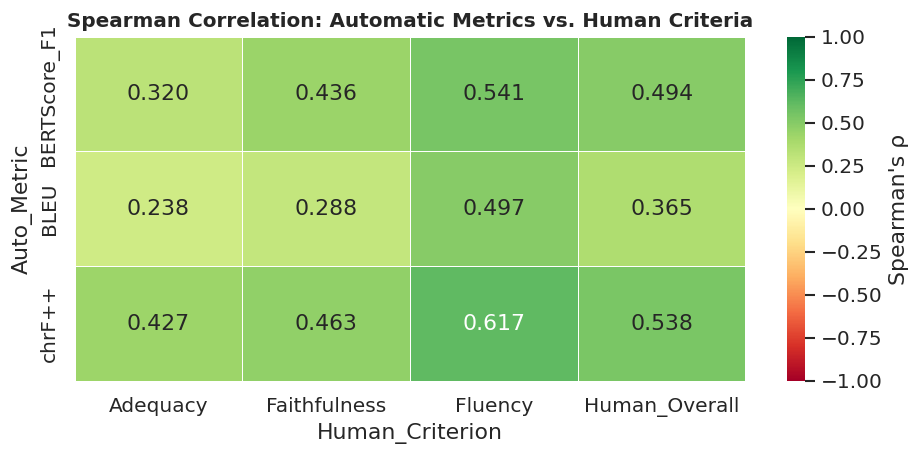

💾 Saved: spearman_correlation_heatmap.png


In [32]:
# ── 7B: Correlation heatmap ───────────────────────────────────────────────────
pivot_corr = df_corr.pivot(index="Auto_Metric",
                            columns="Human_Criterion",
                            values="Spearman_rho")

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    pivot_corr, annot=True, fmt=".3f",
    cmap="RdYlGn", vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    cbar_kws={'label': "Spearman's ρ"}
)
ax.set_title("Spearman Correlation: Automatic Metrics vs. Human Criteria",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("spearman_correlation_heatmap.png", bbox_inches='tight')
plt.show()
print("💾 Saved: spearman_correlation_heatmap.png")

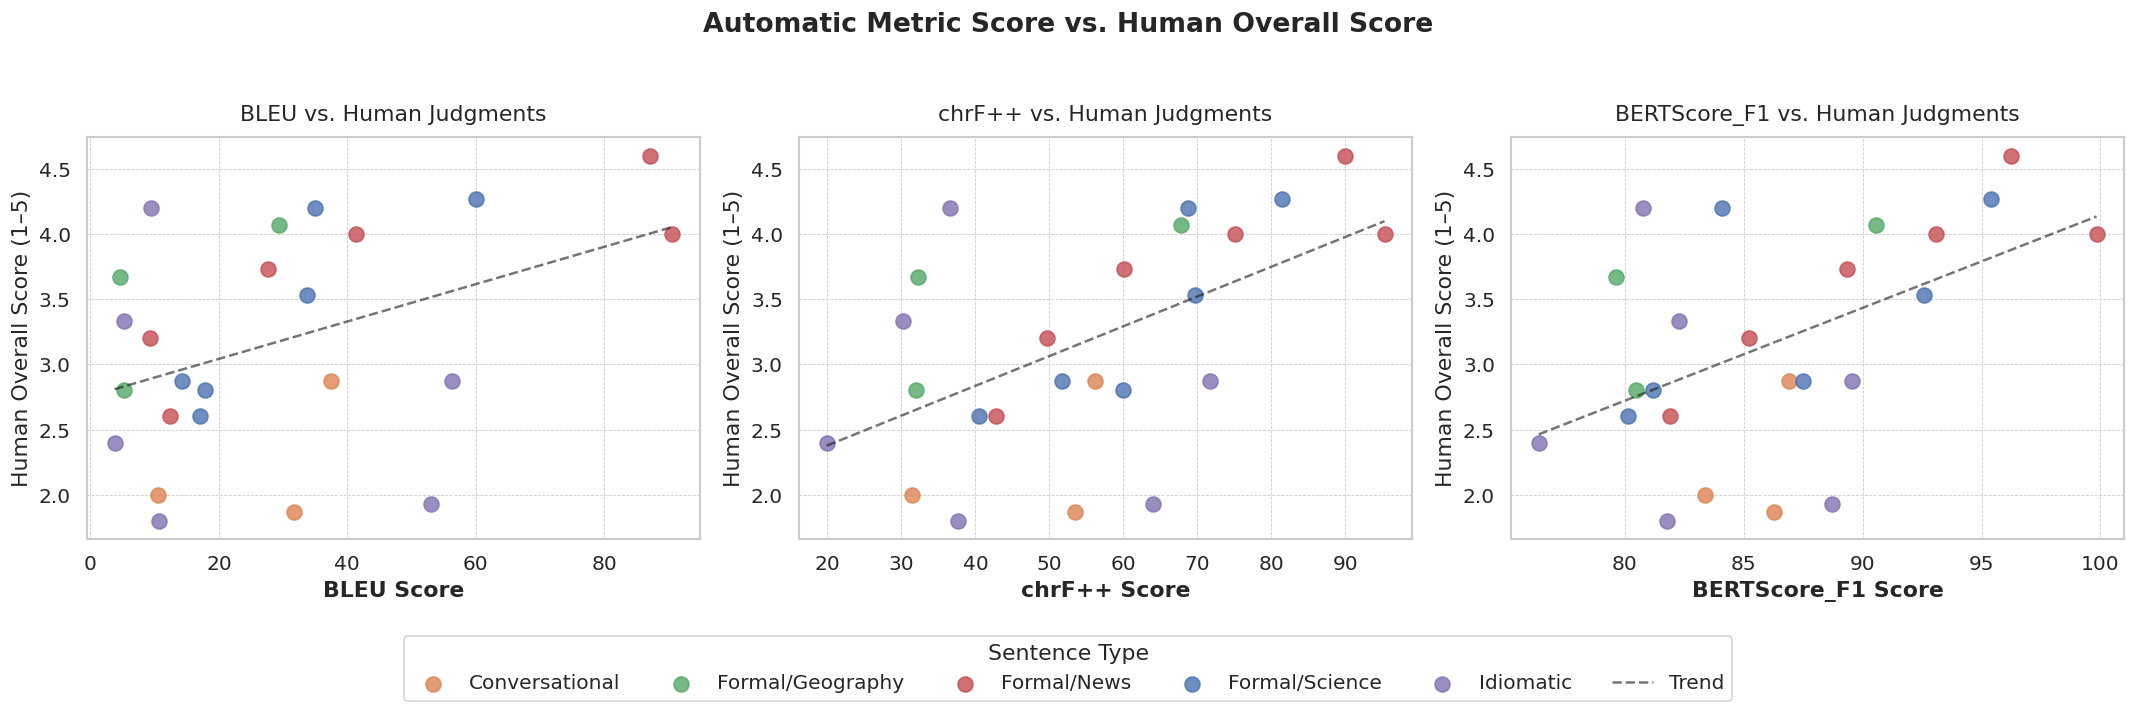

💾 Saved plot to: scatter_auto_vs_human.png


In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 8 — VISUALIZATION & DISCREPANCY ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

# ── 8A: Scatter plot — Auto Metrics vs Human Overall ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle("Automatic Metric Score vs. Human Overall Score",
             fontsize=16, fontweight='bold')

# Define a color palette for each sentence type
type_palette = {
    "Formal/Science":     '#4C72B0',
    "Formal/Geography":   '#55A868',
    "Formal/News":        '#C44E52',
    "Conversational":     '#DD8452',
    "Idiomatic":          '#8172B2',
}
auto_metrics = ["BLEU", "chrF++", "BERTScore_F1"]

for ax, metric in zip(axes, auto_metrics):
    # FIX: Group by "Type", not "Sentence_Type"
    for stype, group in df_merged.groupby("Type"):
        ax.scatter(
            group[metric], group["Human_Overall"],
            label=stype, alpha=0.8, s=80,
            color=type_palette.get(stype, 'grey')
        )
    # Add regression line to show the trend
    x_vals = df_merged[metric].dropna()
    y_vals = df_merged["Human_Overall"].dropna()
    m, b   = np.polyfit(x_vals, y_vals, 1)
    ax.plot(np.sort(x_vals), m * np.sort(x_vals) + b, 'k--', linewidth=1.5, alpha=0.6, label='Trend')

    ax.set_xlabel(f"{metric} Score", fontweight='bold')
    ax.set_ylabel("Human Overall Score (1–5)")
    ax.set_title(f"{metric} vs. Human Judgments", pad=10)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6,
           bbox_to_anchor=(0.5, -0.08), title="Sentence Type")

plt.tight_layout(rect=[0, 0.05, 1, 0.95]) # Adjust layout to make room for legend
plt.savefig("scatter_auto_vs_human.png", bbox_inches='tight', dpi=150)
plt.show()
print("💾 Saved plot to: scatter_auto_vs_human.png")

---
## Section 8 — Discrepancy Analysis
### Where Automatic Metrics Fail but Humans Succeed (and vice versa)

This section identifies **critical mismatches** between metric ranks and human judgments — the core analytical contribution of your report.

**Expected discrepancy patterns to look for:**

| Pattern | Sentence Type | Why it happens |
|---------|--------------|----------------|
| Low BLEU, High Human | Idiomatic (S7, S8) | Valid cultural paraphrase; no lexical overlap with reference |
| High BLEU, Low Human | Formal (S1–S5) | Over-literal, unnatural Hindi; exact n-gram but poor fluency |
| Low BERTScore, High Human | Conversational (S6) | Slang/code-switching may not be well represented in mBERT |
| BLEU=0, High Human | Any idiomatic | Complete synonym substitution — BLEU's binary failure mode |

In [35]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 8 — DISCREPANCY ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

# ── 8A: Compute rank discrepancy (|rank_BLEU - rank_Human|) ─────────────────

df_disc = df_merged.copy()
df_disc["Rank_BLEU"]         = df_disc["BLEU"].rank(ascending=False)
df_disc["Rank_BERTScore"]    = df_disc["BERTScore_F1"].rank(ascending=False)
df_disc["Rank_Human"]        = df_disc["Human_Overall"].rank(ascending=False)
df_disc["Rank_Diff_BLEU"]    = (df_disc["Rank_BLEU"]    - df_disc["Rank_Human"]).abs()
df_disc["Rank_Diff_BERT"]    = (df_disc["Rank_BERTScore"] - df_disc["Rank_Human"]).abs()

# Flag large discrepancies (difference > 8 positions out of 24 total items)
THRESHOLD = 8
df_disc["BLEU_Discrepancy"] = df_disc["Rank_Diff_BLEU"] > THRESHOLD
df_disc["BERT_Discrepancy"] = df_disc["Rank_Diff_BERT"] > THRESHOLD

# ── 8C: Show Top Discrepant Cases ─────────────────────────────────────────────
print("\n" + "="*80)
print("🔴 Cases with LARGEST BLEU vs. Human rank discrepancy:")
print("   (These are examples where BLEU was a poor predictor of human judgment)")
print("="*80)
display(
    df_disc.sort_values("Rank_Diff_BLEU", ascending=False)
    # FIX: Use "ID" and "Type" for column names
    [["ID", "Type", "Model",
      "BLEU", "Human_Overall", "Rank_BLEU", "Rank_Human", "Rank_Diff_BLEU"]]
    .head(5)
)

print("\n" + "="*80)
print("🔵 Cases with LARGEST BERTScore vs. Human rank discrepancy:")
print("   (These are examples where even a modern metric like BERTScore struggled)")
print("="*80)
display(
    df_disc.sort_values("Rank_Diff_BERT", ascending=False)
    # FIX: Use "ID" and "Type" for column names
    [["ID", "Type", "Model",
      "BERTScore_F1", "Human_Overall", "Rank_BERTScore", "Rank_Human", "Rank_Diff_BERT"]]
    .head(5)
)


🔴 Cases with LARGEST BLEU vs. Human rank discrepancy:
   (These are examples where BLEU was a poor predictor of human judgment)


,ID,Type,Model,BLEU,Human_Overall,Rank_BLEU,Rank_Human,Rank_Diff_BLEU
22,S7,Idiomatic,mBART_50,53.09,1.93,5.0,22.0,17.0
15,S8,Idiomatic,NLLB_200,9.43,4.20,19.0,3.5,15.5
18,S3,Formal/Geography,mBART_50,4.62,3.67,23.0,9.0,14.0
5,S6,Conversational,Helsinki_NLP,31.62,1.87,10.0,23.0,13.0
14,S7,Idiomatic,NLLB_200,56.33,2.87,4.0,14.0,10.0



🔵 Cases with LARGEST BERTScore vs. Human rank discrepancy:
   (These are examples where even a modern metric like BERTScore struggled)


,ID,Type,Model,BERTScore_F1,Human_Overall,Rank_BERTScore,Rank_Human,Rank_Diff_BERT
15,S8,Idiomatic,NLLB_200,80.74,4.20,20.0,3.5,16.5
18,S3,Formal/Geography,mBART_50,79.61,3.67,23.0,9.0,14.0
22,S7,Idiomatic,mBART_50,88.70,1.93,9.0,22.0,13.0
5,S6,Conversational,Helsinki_NLP,86.27,1.87,12.0,23.0,11.0
8,S1,Formal/Science,NLLB_200,84.09,4.20,14.0,3.5,10.5


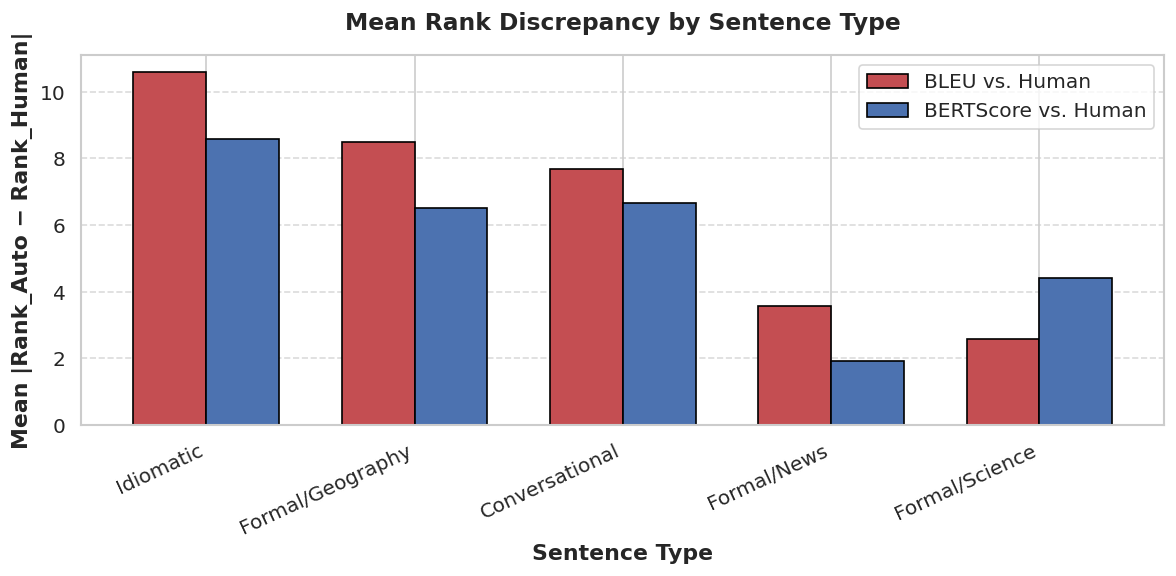

💾 Saved plot: discrepancy_by_sentence_type.png

  DISCREPANCY ANALYSIS SUMMARY

  Total translation pairs evaluated : 24
  BLEU rank discrepancies (Δ > 8): 6 (25.0%)
  BERTScore rank discrepancies      : 5 (20.8%)

  Mean BLEU discrepancy — Idiomatic  : 10.58
  Mean BLEU discrepancy — Formal     : 4.17

  Interpretation:
  → Higher discrepancy on Idiomatic sentences confirms BLEU's inability
    to handle non-literal, culturally-appropriate paraphrasing.
  → This is a key finding for your report's discussion section.

📊 Model-Averaged Scores (for report tables):


,BLEU,chrF++,BERTScore_F1,Adequacy,Fluency,Faithfulness,Human_Overall
Model,,,,,,,
NLLB_200,44.51,68.41,89.57,3.72,4.10,3.82,3.88
mBART_50,30.42,55.39,87.11,3.15,3.40,2.82,3.12
Helsinki_NLP,13.02,40.94,82.45,2.33,2.98,2.25,2.52



💾 Saved: full_evaluation_results.csv
💾 Saved: spearman_correlations.csv
💾 Saved: discrepancy_analysis.csv
💾 Saved: model_average_scores.csv

✅ All results exported successfully!
   📁 You can download these from the Kaggle Output panel (right sidebar).


In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 9 — ADVANCED ANALYSIS & EXPORT
# ══════════════════════════════════════════════════════════════════════════════

# ── 9A: Average discrepancy by sentence type ─────────────────────────────────
# FIX: Group by "Type", not "Sentence_Type"
disc_by_type = (
    df_disc
    .groupby("Type")[["Rank_Diff_BLEU", "Rank_Diff_BERT"]]
    .mean()
    .round(2)
    .sort_values("Rank_Diff_BLEU", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
disc_by_type.plot(kind='bar', ax=ax,
                  color={'Rank_Diff_BLEU': '#C44E52', 'Rank_Diff_BERT': '#4C72B0'},
                  edgecolor='black', width=0.7)
ax.set_title("Mean Rank Discrepancy by Sentence Type",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Sentence Type", fontweight='bold')
ax.set_ylabel("Mean |Rank_Auto − Rank_Human|", fontweight='bold')
ax.legend(["BLEU vs. Human", "BERTScore vs. Human"])
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("discrepancy_by_sentence_type.png", bbox_inches='tight', dpi=150)
plt.show()
print("💾 Saved plot: discrepancy_by_sentence_type.png")

# ── 9B: Narrative discrepancy summary ────────────────────────────────────────
print("\n" + "=" * 70)
print("  DISCREPANCY ANALYSIS SUMMARY")
print("=" * 70)

n_bleu_disc = df_disc["BLEU_Discrepancy"].sum()
n_bert_disc = df_disc["BERT_Discrepancy"].sum()
total       = len(df_disc)

print(f"\n  Total translation pairs evaluated : {total}")
print(f"  BLEU rank discrepancies (Δ > {THRESHOLD}): {n_bleu_disc} "
      f"({100*n_bleu_disc/total:.1f}%)")
print(f"  BERTScore rank discrepancies      : {n_bert_disc} "
      f"({100*n_bert_disc/total:.1f}%)")

# FIX: Filter by "Type", not "Sentence_Type"
idiomatic_bleu = df_disc[df_disc["Type"]=="Idiomatic"]["Rank_Diff_BLEU"].mean()
formal_bleu    = df_disc[df_disc["Type"].str.startswith("Formal")]["Rank_Diff_BLEU"].mean()

print(f"\n  Mean BLEU discrepancy — Idiomatic  : {idiomatic_bleu:.2f}")
print(f"  Mean BLEU discrepancy — Formal     : {formal_bleu:.2f}")
print("\n  Interpretation:")
print("  → Higher discrepancy on Idiomatic sentences confirms BLEU's inability")
print("    to handle non-literal, culturally-appropriate paraphrasing.")
print("  → This is a key finding for your report's discussion section.")
print("=" * 70)

# ── 9C: Create model-averaged scores table for the report ────────────────────
df_model_avg = (
    df_merged
    .groupby("Model")[["BLEU", "chrF++", "BERTScore_F1", "Adequacy", "Fluency", "Faithfulness", "Human_Overall"]]
    .mean()
    .round(2)
    .sort_values("Human_Overall", ascending=False)
)
print("\n📊 Model-Averaged Scores (for report tables):")
display(df_model_avg)


# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 10 — EXPORT ALL RESULTS
# ══════════════════════════════════════════════════════════════════════════════

# File 1: Full merged results (metrics + human scores)
df_merged.to_csv("full_evaluation_results.csv", index=False, encoding='utf-8-sig')
print("\n💾 Saved: full_evaluation_results.csv")

# File 2: Spearman correlation table
df_corr.to_csv("spearman_correlations.csv", index=False)
print("💾 Saved: spearman_correlations.csv")

# File 3: Discrepancy analysis
# FIX: Use "ID" and "Type" for column names
df_disc_export = df_disc[[
    "ID", "Type", "Model",
    "BLEU", "BERTScore_F1", "Human_Overall",
    "Rank_BLEU", "Rank_BERTScore", "Rank_Human",
    "Rank_Diff_BLEU", "Rank_Diff_BERT",
    "BLEU_Discrepancy", "BERT_Discrepancy"
]].copy()
df_disc_export.to_csv("discrepancy_analysis.csv", index=False)
print("💾 Saved: discrepancy_analysis.csv")

# File 4: Model-averaged scores
df_model_avg.to_csv("model_average_scores.csv")
print("💾 Saved: model_average_scores.csv")

print("\n✅ All results exported successfully!")
print("   📁 You can download these from the Kaggle Output panel (right sidebar).")